导出

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

Solving Timoshenko beam problem...
CFL number: 0.0318


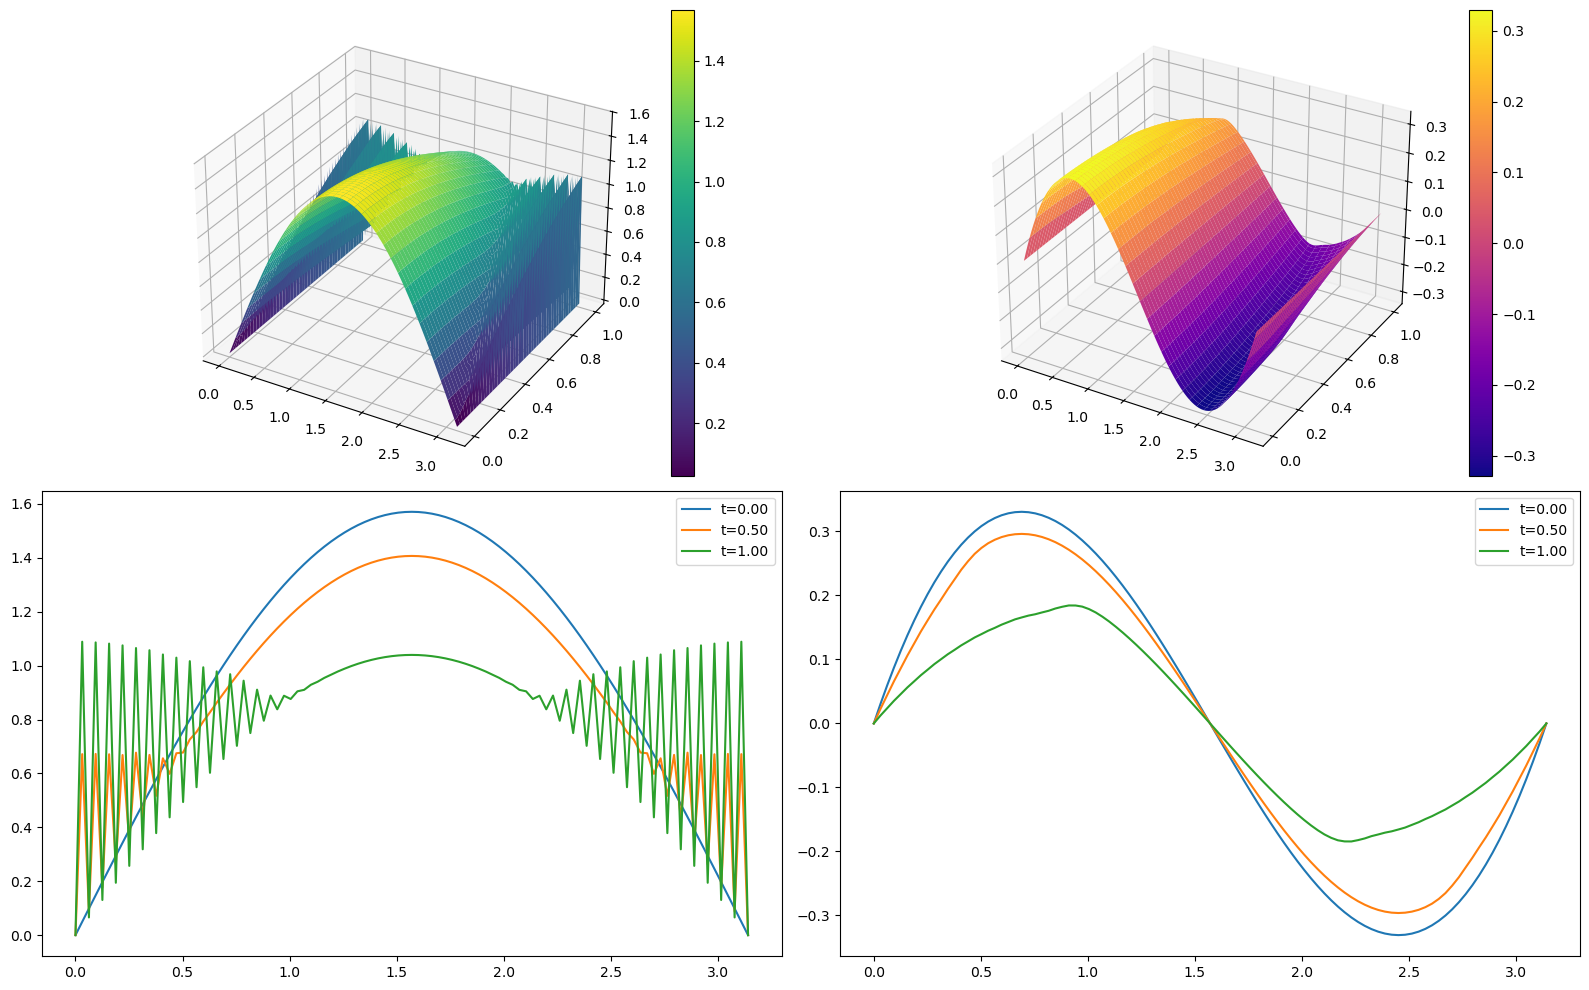

Results saved to timoshenko_results.npz
✅ Readable CSV files exported to: results_deepseek_csv
All computations completed.


In [4]:
def solve_timoshenko_fdm(Nx=101, Nt=1001):
    L = np.pi
    T = 1.0
    
    dx = L / (Nx - 1)
    dt = T / (Nt - 1)
    
    cfl = dt / dx
    print(f"CFL number: {cfl:.4f}")
    if cfl > 1.0:
        print("Warning: CFL condition may be violated. Consider reducing dt.")
    
    x = np.linspace(0, L, Nx)
    t = np.linspace(0, T, Nt)
    
    ω = np.zeros((Nx, Nt))
    θ = np.zeros((Nx, Nt))
    
    ω[:, 0] = (np.pi/2) * np.sin(x)
    θ[:, 0] = (np.pi/2) * np.cos(x) + (x - np.pi/2)
    
    ω_x = np.zeros(Nx)
    ω_xx = np.zeros(Nx)
    θ_x = np.zeros(Nx)
    θ_xx = np.zeros(Nx)
    
    for i in range(1, Nx-1):
        ω_x[i] = (ω[i+1, 0] - ω[i-1, 0]) / (2*dx)
        θ_x[i] = (θ[i+1, 0] - θ[i-1, 0]) / (2*dx)
        ω_xx[i] = (ω[i+1, 0] - 2*ω[i, 0] + ω[i-1, 0]) / (dx**2)
        θ_xx[i] = (θ[i+1, 0] - 2*θ[i, 0] + θ[i-1, 0]) / (dx**2)
    
    ω_x[0] = (ω[1, 0] - ω[0, 0]) / dx
    ω_x[-1] = (ω[-1, 0] - ω[-2, 0]) / dx
    θ_x[0] = (θ[1, 0] - θ[0, 0]) / dx
    θ_x[-1] = (θ[-1, 0] - θ[-2, 0]) / dx
    
    ω_xx[0] = (ω[2, 0] - 2*ω[1, 0] + ω[0, 0]) / (dx**2)
    ω_xx[-1] = (ω[-1, 0] - 2*ω[-2, 0] + ω[-3, 0]) / (dx**2)
    θ_xx[0] = (θ[2, 0] - 2*θ[1, 0] + θ[0, 0]) / (dx**2)
    θ_xx[-1] = (θ[-1, 0] - 2*θ[-2, 0] + θ[-3, 0]) / (dx**2)
    
    θ_tt = θ_xx - (θ[:, 0] - ω_x)
    
    S = θ[:, 0] - ω_x
    S_x = np.zeros(Nx)
    for i in range(1, Nx-1):
        S_x[i] = (S[i+1] - S[i-1]) / (2*dx)
    
    g_0 = np.cos(0) - (np.pi/2)*np.sin(x)*np.cos(0)
    ω_tt = g_0 - S_x
    
    ω[:, 1] = ω[:, 0] + (dt**2/2)*ω_tt
    θ[:, 1] = θ[:, 0] + (dt**2/2)*θ_tt
    
    ω[0, 1] = 0
    ω[-1, 1] = 0
    θ[0, 1] = 0
    θ[-1, 1] = 0
    
    for n in range(1, Nt-1):
        g_n = np.cos(t[n]) - (np.pi/2)*np.sin(x)*np.cos(t[n])
        
        for i in range(1, Nx-1):
            ω_x_curr = (ω[i+1, n] - ω[i-1, n]) / (2*dx)
            ω_xx_curr = (ω[i+1, n] - 2*ω[i, n] + ω[i-1, n]) / (dx**2)
            θ_xx_curr = (θ[i+1, n] - 2*θ[i, n] + θ[i-1, n]) / (dx**2)
            
            S = θ[i, n] - ω_x_curr
            S_im1 = θ[i-1, n] - ((ω[i, n] - ω[i-2, n])/(2*dx)) if i>1 else 0
            S_ip1 = θ[i+1, n] - ((ω[i+2, n] - ω[i, n])/(2*dx)) if i<Nx-2 else 0
            S_x_curr = (S_ip1 - S_im1) / (2*dx)
            
            θ[i, n+1] = 2*θ[i, n] - θ[i, n-1] + dt**2 * (θ_xx_curr - (θ[i, n] - ω_x_curr))
            ω[i, n+1] = 2*ω[i, n] - ω[i, n-1] + dt**2 * (g_n[i] - S_x_curr)
        
        ω[0, n+1] = 0
        ω[-1, n+1] = 0
        θ[0, n+1] = 0
        θ[-1, n+1] = 0
        
        ω[:, n+1] = 0.999*ω[:, n+1] + 0.001*ω[:, n]
        θ[:, n+1] = 0.999*θ[:, n+1] + 0.001*θ[:, n]
    
    return x, t, ω, θ


def visualize_results(x, t, ω, θ):
    X, T = np.meshgrid(x, t, indexing='ij')
    
    fig = plt.figure(figsize=(16, 10))
    
    ax1 = fig.add_subplot(221, projection='3d')
    surf1 = ax1.plot_surface(X, T, ω, cmap='viridis')
    fig.colorbar(surf1, ax=ax1)
    
    ax2 = fig.add_subplot(222, projection='3d')
    surf2 = ax2.plot_surface(X, T, θ, cmap='plasma')
    fig.colorbar(surf2, ax=ax2)
    
    ax3 = fig.add_subplot(223)
    for idx in [0, len(t)//2, -1]:
        ax3.plot(x, ω[:, idx], label=f"t={t[idx]:.2f}")
    ax3.legend()
    
    ax4 = fig.add_subplot(224)
    for idx in [0, len(t)//2, -1]:
        ax4.plot(x, θ[:, idx], label=f"t={t[idx]:.2f}")
    ax4.legend()
    
    plt.tight_layout()
    plt.show()


def export_results(x, t, ω, θ, filename='timoshenko_results.npz'):
    np.savez(filename, x=x, t=t, omega=ω, theta=θ)
    print(f"Results saved to {filename}")


# ✅ ✅ ✅ 可读型 CSV 导出函数（最终版）
def export_results_csv_readable(x, t, ω, θ, folder_name="results_csv"):
    os.makedirs(folder_name, exist_ok=True)

    # ω(x,t)
    df_omega = pd.DataFrame(
        ω,
        index=np.round(x, 6),
        columns=np.round(t, 6)
    )
    df_omega.index.name = "x"
    df_omega.columns.name = "t"
    df_omega.to_csv(os.path.join(folder_name, "omega_full.csv"))

    # θ(x,t)
    df_theta = pd.DataFrame(
        θ,
        index=np.round(x, 6),
        columns=np.round(t, 6)
    )
    df_theta.index.name = "x"
    df_theta.columns.name = "t"
    df_theta.to_csv(os.path.join(folder_name, "theta_full.csv"))

    # 最终时刻数据
    pd.DataFrame({
        "x": x,
        "omega_final": ω[:, -1]
    }).to_csv(os.path.join(folder_name, "omega_final.csv"), index=False)

    pd.DataFrame({
        "x": x,
        "theta_final": θ[:, -1]
    }).to_csv(os.path.join(folder_name, "theta_final.csv"), index=False)

    print("✅ Readable CSV files exported to:", folder_name)


# =============================
# Main
# =============================
if __name__ == "__main__":
    print("Solving Timoshenko beam problem...")
    
    x, t, ω, θ = solve_timoshenko_fdm(Nx=101, Nt=1001)
    
    visualize_results(x, t, ω, θ)
    
    export_results(x, t, ω, θ)
    
    export_results_csv_readable(x, t, ω, θ, folder_name="results_deepseek_csv")
    
    print("All computations completed.")
